# RL Group Project: Clinical Treatment Optimisation — Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity, plus a creative extension:

- **Configuration A** — Tabular Sepsis MDP (716 discrete states, 25 actions): Policy Iteration, Q-Learning.
- **Configuration B** — Continuous observation space (47-dimensional) with three clinical reality wrappers: DQN (with Double DQN updates) and Dueling DQN.
- **Creative Extension** — Clinical interpretability analysis of treatment preferences.

---
### Group N
```
Student 1: Fausto Gomez, 20221915
Student 2: Miguel Marques, 20221839
Student 3: Tomás Gonçalves, 20221894
Student 4: Tomás Vitorino, 20250495
```


---
## 0. Setup & Imports

In [14]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn torch scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import copy
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

# ── Fixed seeds for full reproducibility ──────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print(f'Config: sofa_bias={SOFA_BIAS}, lam={LAM}, gamma={GAMMA}')
print('Setup complete!')

Device : cpu
ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Config: sofa_bias=5.0, lam=0.02, gamma=1.0
Setup complete!


---
## 1. Environment Exploration

`ICU-Sepsis-v2` is a benchmark MDP built from real MIMIC-III patient data. Each episode simulates one ICU patient. The agent observes a discrete integer state (0–715) and selects one of 25 treatment actions (5 vasopressor levels × 5 IV fluid dose levels). The reward is sparse: **+1 at survival, 0 at death**, with a small intensity penalty `lam=0.02` at each step to discourage overtreatment.

In [15]:
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

raw    = env.unwrapped
P      = raw._tx_mat                   # (716, 25, 716)  P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716)
R      = (P * R_sasp).sum(axis=2)     # (716, 25)  E[r|s,a]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


In [16]:
print(f'Observation space : {env.observation_space}')
print(f'Action space      : {env.action_space}')
print(f'Transition matrix : {P.shape}  (S x A x S\'')
print(f'Reward range      : [{R.min():.3f}, {R.max():.3f}]')

Observation space : Discrete(716)
Action space      : Discrete(25)
Transition matrix : (716, 25, 716)  (S x A x S'
Reward range      : [-0.020, 0.708]


In [17]:
# ── Random baseline (Config A) ────────────────────────────────────────────────
def run_random_baseline_A(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r); lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)

rand_returns_A, rand_lengths_A = run_random_baseline_A()
RAND_A_RETURN   = float(np.mean(rand_returns_A))
RAND_A_SURVIVAL = float(np.mean(rand_returns_A > 0)) * 100
print(f'Random baseline (Config A) | Return={RAND_A_RETURN:.4f} | Survival={RAND_A_SURVIVAL:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random baseline (Config A) | Return=0.5963 | Survival=69.8%


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


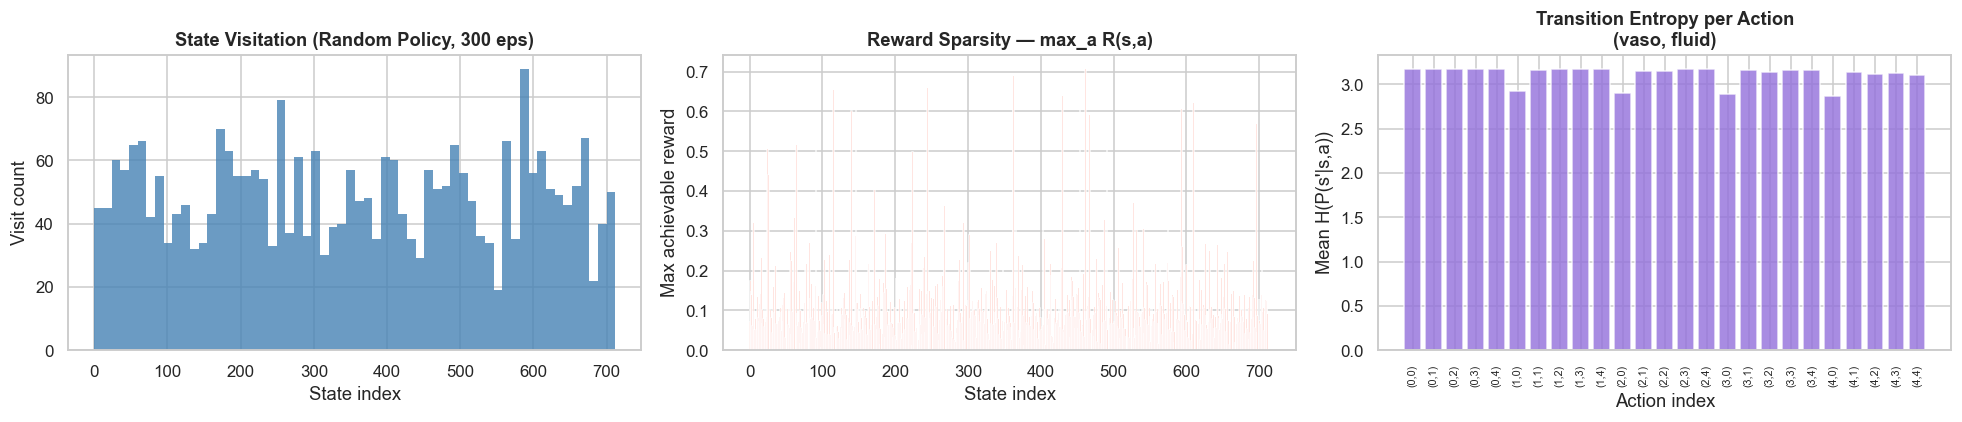

In [18]:
# ── Environment visualisation ─────────────────────────────────────────────────
import scipy.stats

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical_states = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical_states, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('State Visitation (Random Policy, 300 eps)', fontweight='bold')
axes[0].set_xlabel('State index'); axes[0].set_ylabel('Visit count')

# Reward sparsity
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_title('Reward Sparsity — max_a R(s,a)', fontweight='bold')
axes[1].set_xlabel('State index'); axes[1].set_ylabel('Max achievable reward')

# Transition entropy per action
entropy_per_action = np.array([
    np.mean([scipy.stats.entropy(P[s, a] + 1e-12) for s in range(N_STATES - 2)])
    for a in range(N_ACTIONS)
])
action_labels = [f'({i//5},{i%5})' for i in range(N_ACTIONS)]
axes[2].bar(range(N_ACTIONS), entropy_per_action, color='mediumpurple', alpha=0.8)
axes[2].set_title('Transition Entropy per Action\n(vaso, fluid)', fontweight='bold')
axes[2].set_xlabel('Action index'); axes[2].set_ylabel('Mean H(P(s\'|s,a))')
axes[2].set_xticks(range(N_ACTIONS))
axes[2].set_xticklabels(action_labels, rotation=90, fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular RL

The following algorithms were implemented:

| Property | Policy Iteration | Q-Learning |
|---|---|---|
| Type | Model-based | Model-free |
| Policy type | Greedy | ε-greedy (off-policy) |
| Convergence | Exact | Asymptotic (GLIE) |
| Sample efficiency | No data needed | Many episodes required |

As we have access to the full MDP model, **Policy Iteration** is a natural first choice: it uses the known transition dynamics to compute exact value updates and converges in a handful of sweeps. However, in most real-world problems, this model is never available. **Q-Learning** was therefore chosen as the second algorithm to directly measure what is lost when the model is taken away: instead of computing exact expectations, it must estimate the same optimal policy through repeated trial and error, relying solely on sampled transitions from the environment.

In [19]:
def build_P(env):
    # absorbing states: T[s, a, s] == 1 for all actions
    # these are the true terminal states (survival + death)
    terminal_states = set(
        s for s in range(N_STATES)
        if np.all(P[s, :, s] == 1.0)
    )
    print(f'Terminal states found: {len(terminal_states)}')

    P_dict= {}
    for s in range(N_STATES):
        P_dict[s] = {}
        for a in range(N_ACTIONS):
            transitions = []
            for s_ in range(N_STATES):
                prob = float(P[s, a, s_])
                if prob > 0:
                    r    = float(R_sasp[s, a, s_])
                    done = s_ in terminal_states
                    transitions.append((prob, s_, r, done))
            P_dict[s][a] = transitions if transitions else [(1.0, s, 0.0, False)]
    return P_dict

In [20]:
# ── Fixed evaluation function (Config A) ──────────────────────────────────────
def evaluate_tabular(Q, n_episodes=1000, seed=SEED):
    """
    Greedy evaluation of a tabular Q-table.
    Returns (mean_return, survival_pct, mean_ep_length).
    """
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = int(np.argmax(Q[obs]))
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r); lengths.append(steps)
    env_eval.close()
    returns = np.array(returns)
    return float(np.mean(returns)), float(np.mean(returns > 0)) * 100, float(np.mean(lengths))

## Config A — Algorithm 1: Policy Iteration
Policy Iteration alternates between two steps: **policy evaluation**, which computes
the exact state-value function for the current policy by sweeping through all states
until convergence, and **policy improvement**, which updates the policy greedily with
respect to those values.

$$V(s) \leftarrow \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma V(s') \Big]$$

$$\pi(s) \leftarrow \arg\max_{a} \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma V(s') \Big]$$

Unlike Q-Learning, Policy Iteration requires no exploration — it computes exact
expectations directly from the known transition model, making ε-greedy unnecessary.
It is guaranteed to converge to the optimal policy in a finite number of sweeps.

**Hyperparameter justification:** `γ=1.0` is set by the environment (survival reward
not discounted). Convergence threshold `θ=1e-6` determines when policy evaluation
is considered stable — small enough to ensure precision without unnecessary
computation. No learning rate α is needed since updates are exact, not stochastic.

In [21]:
def train_PI(gamma=GAMMA, theta=1e-6, seed=SEED):
    np.random.seed(seed)
    env_pi = make_sepsis_env().unwrapped
    P      = build_P(env_pi)                      

    def compute_value_function_policy_evaluation(policy, value_table):
        while True:
            updated_value_table = np.copy(value_table)
            for s in range(N_STATES):
                a = policy[s]
                value_table[s] = sum([
                    prob * (r + gamma * updated_value_table[s_])
                    for prob, s_, r, _ in P[s][a]   # ← P not env_pi.P
                ])
            if np.sum(np.fabs(updated_value_table - value_table)) <= theta:
                break
        return value_table

    def extract_policy(value_table):
        policy = np.zeros(N_STATES, dtype=int)
        Q      = np.zeros((N_STATES, N_ACTIONS))
        for s in range(N_STATES):
            q_values = [
                sum([prob * (r + gamma * value_table[s_])
                     for prob, s_, r, _ in P[s][a]]) # ← P not env_pi.P
                for a in range(N_ACTIONS)
            ]
            Q[s]      = q_values
            policy[s] = np.argmax(q_values)
        return policy, Q

    policy         = np.zeros(N_STATES, dtype=int)
    value_function = np.zeros(N_STATES)
    convergence_deltas, eval_log = [], []

    for i in range(1000):
        old_value      = value_function.copy()
        value_function = compute_value_function_policy_evaluation(policy, value_function)
        new_policy, Q  = extract_policy(value_function)
        delta = np.max(np.abs(old_value - value_function))
        convergence_deltas.append(delta)
        mr, sr, _ = evaluate_tabular(Q, n_episodes=500)
        eval_log.append((i + 1, mr, sr))
        print(f'[PI] iter={i+1:>3} | delta={delta:.8f} | return={mr:.4f} | survival={sr:.1f}%')
        if np.all(policy == new_policy):
            print(f'\nPolicy converged after {i+1} iterations.')
            break
        policy = new_policy

    env_pi.close()
    return Q, np.array(convergence_deltas), eval_log, []


print('Training Policy Iteration...')
Q_PI, PI_deltas, PI_eval, _ = train_PI()
PI_mean, PI_surv, PI_len = evaluate_tabular(Q_PI)
print(f'\nPI FINAL | return={PI_mean:.4f} | survival={PI_surv:.1f}% | ep_len={PI_len:.1f}')

Training Policy Iteration...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Terminal states found: 1
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PI] iter=  1 | delta=0.97777159 | return=0.7310 | survival=76.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PI] iter=  2 | delta=0.21348393 | return=0.7174 | survival=75.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PI] iter=  3 | delta=0.02381437 | return=0.7211 | survival=75.6%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PI] iter=  4 | delta=0.00074665 | return=0.7211 | survival=75.6%

Policy converged after 4 iterations.
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean s

## Config A — Algorithm 2: Q-Learning (Off-Policy TD Control)

Q-Learning updates using the **maximum** future Q-value, regardless of which action the behaviour policy would actually take. It learns the optimal Q* directly, independent of exploration noise.

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \Big]$$

**Hyperparameter justification:** `α=0.1` balances convergence speed vs. stability on stochastic transitions. `γ=1.0` is set by the environment (survival reward not discounted). ε decays from 1.0 → 0.01 over 30k episodes via rate 0.9997, reaching ε=0.05 around episode 19k — ensuring thorough early exploration before settling into exploitation.

In [10]:
def train_q_learning(
    n_episodes=30_000, alpha=0.1, gamma=GAMMA,
    eps_start=1.0, eps_end=0.01, eps_decay=0.9997,
    eval_every=500, seed=SEED,
):
    """
    Q-Learning: off-policy TD control.
    Update: Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
    """
    np.random.seed(seed)
    env_train = make_sepsis_env()
    Q         = np.zeros((N_STATES, N_ACTIONS))
    epsilon   = eps_start
    ep_returns, eval_log, eps_log = [], [], []

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            if np.random.rand() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                action = int(np.argmax(Q[obs]))
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr
            # Off-policy: bootstrap on max Q(s')
            Q[obs, action] += alpha * (r + gamma * np.max(Q[next_obs]) * (not done) - Q[obs, action])
            total_r += r; obs = next_obs
        epsilon = max(eps_end, epsilon * eps_decay)
        ep_returns.append(total_r); eps_log.append(epsilon)
        if (ep + 1) % eval_every == 0:
            mr, sr, _ = evaluate_tabular(Q, n_episodes=500)
            eval_log.append((ep + 1, mr, sr))
            print(f'[Q-Learning]    ep={ep+1:>6} | eps={epsilon:.4f} | return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    return Q, np.array(ep_returns), eval_log, eps_log


print('Training Q-Learning...')
Q_ql, ql_train_ret, ql_eval, ql_eps = train_q_learning()
ql_mean, ql_surv, ql_len = evaluate_tabular(Q_ql)
print(f'\nQ-Learning FINAL | return={ql_mean:.4f} | survival={ql_surv:.1f}% | ep_len={ql_len:.1f}')

Training Q-Learning...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=   500 | eps=0.8607 | return=0.5972 | survival=66.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  1000 | eps=0.7408 | return=0.6028 | survival=68.4%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  1500 | eps=0.6376 | return=0.6114 | survival=69.2%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  2000 | eps=0.5488 | return=0.6112 | survival=69.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Q-Learning]    ep=  2500 | e

## Config A — Results & Visualisation

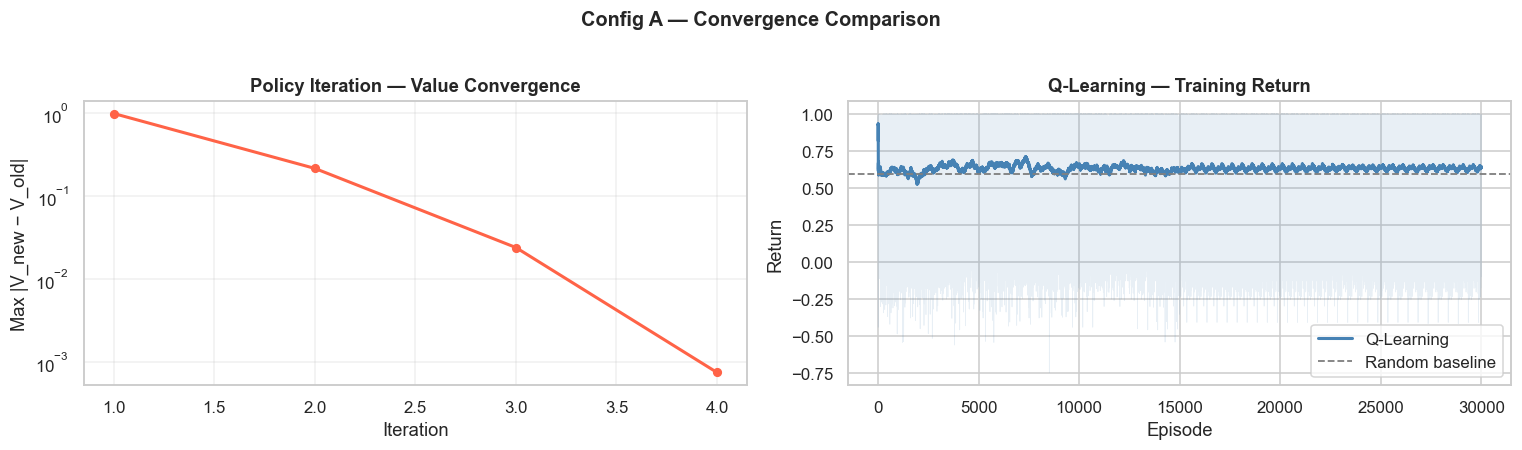

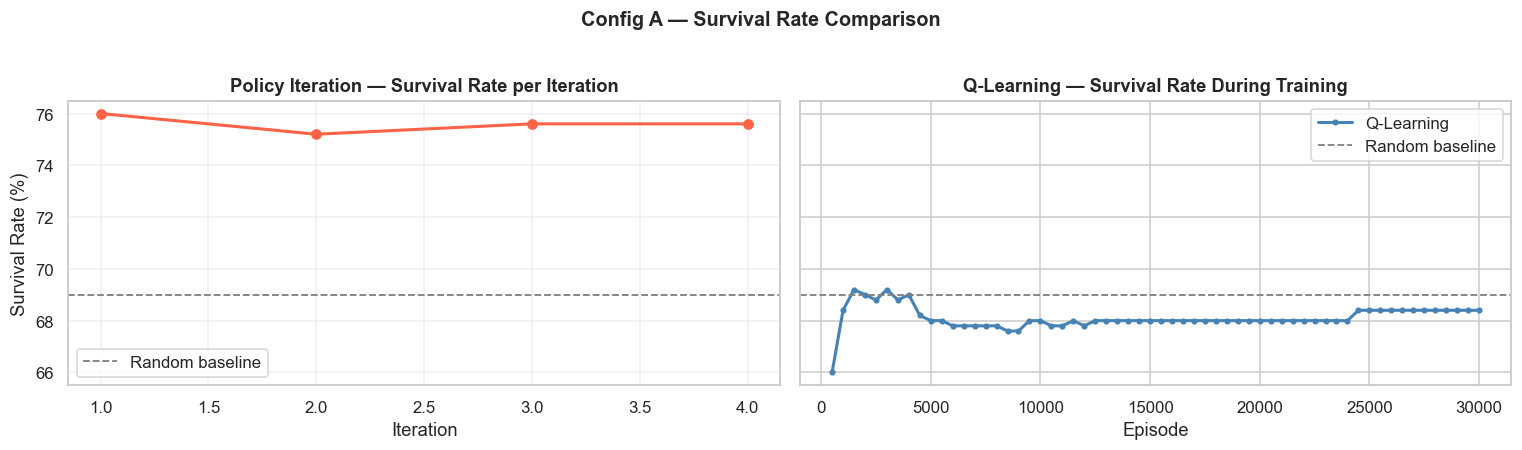

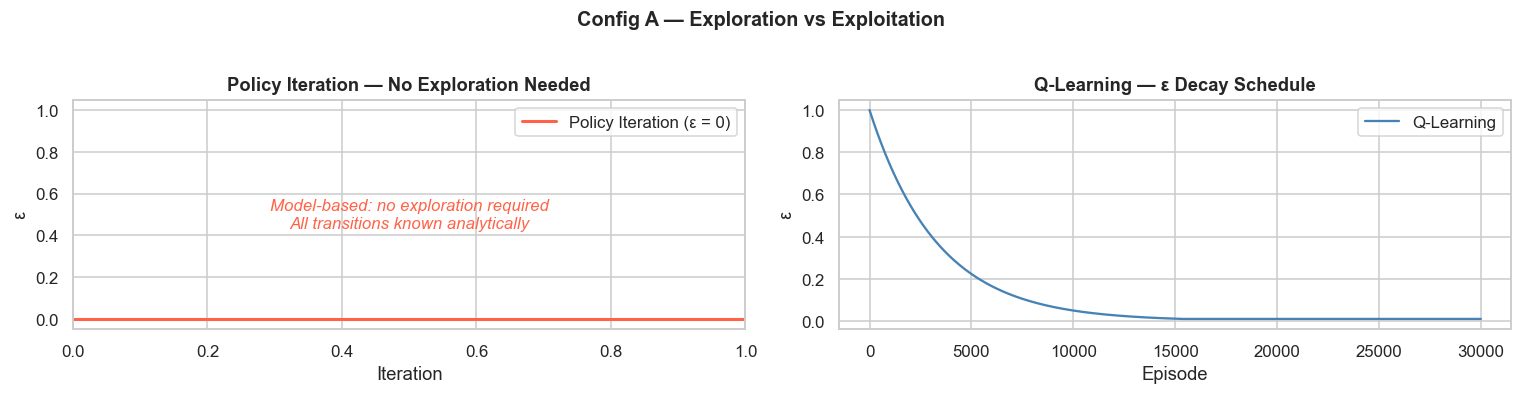

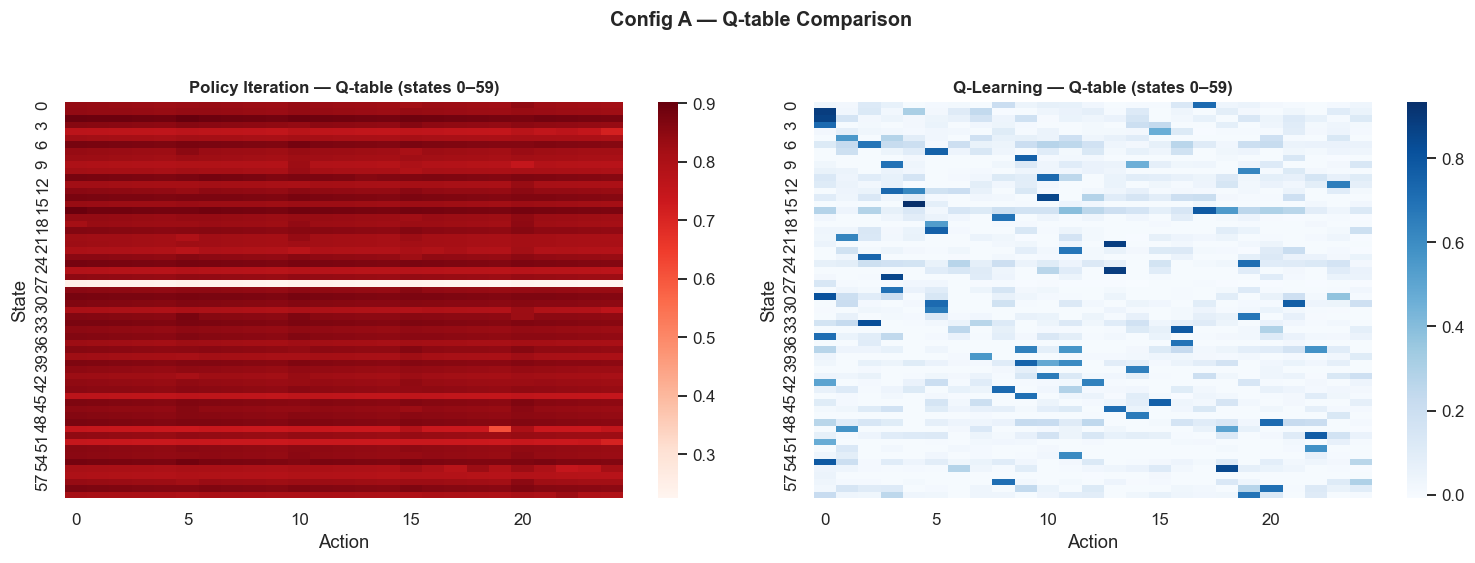

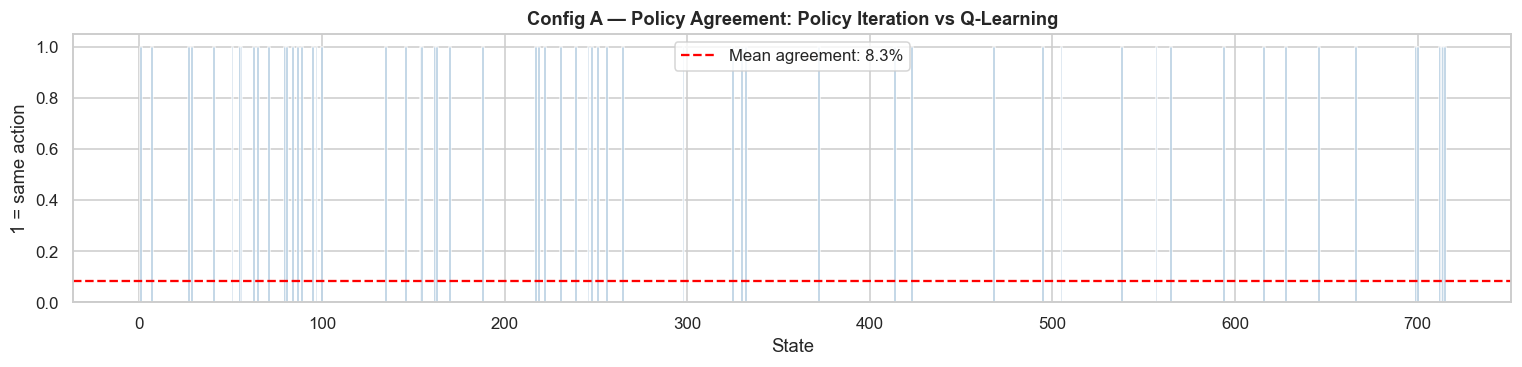

PI vs Q-Learning agreement: 8.3%


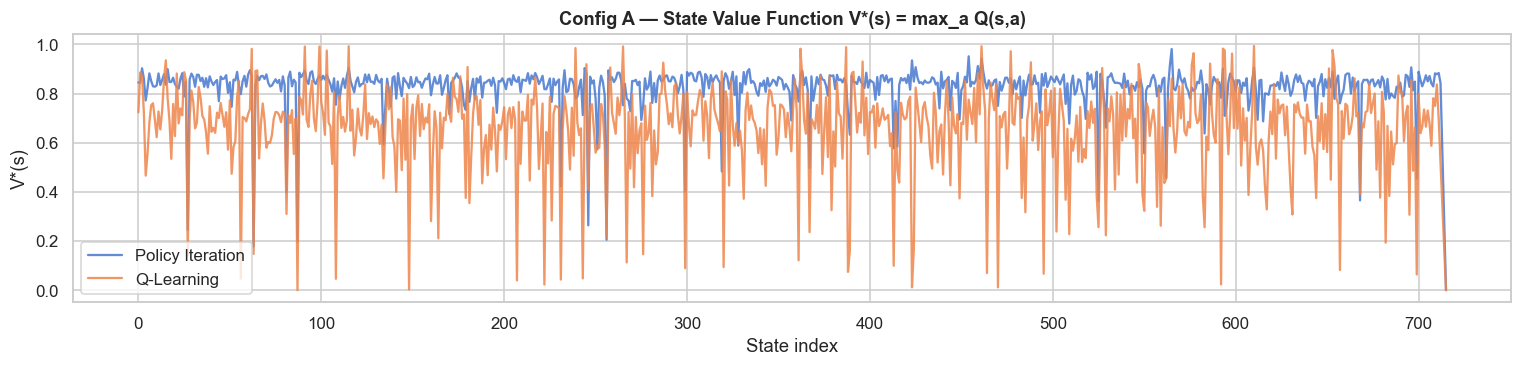

In [11]:
def smooth(x, w=200):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

# ── 1. Convergence comparison ─────────────────────────────────────────────────
# PI: value delta per iteration | QL: smoothed return per episode
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, len(PI_deltas)+1), PI_deltas,
             marker='o', color='tomato', lw=2, markersize=5)
axes[0].set_title('Policy Iteration — Value Convergence', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Max |V_new − V_old|')
axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)

ep = np.arange(1, len(ql_train_ret) + 1)
axes[1].plot(ep, ql_train_ret, alpha=0.12, color='steelblue', lw=0.5)
axes[1].plot(ep, smooth(ql_train_ret, 300), color='steelblue', lw=2, label='Q-Learning')
axes[1].axhline(RAND_A_RETURN, color='grey', ls='--', lw=1.2, label='Random baseline')
axes[1].set_title('Q-Learning — Training Return', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Return'); axes[1].legend()

fig.suptitle('Config A — Convergence Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_convergence_comparison.png', bbox_inches='tight')
plt.show()

# ── 2. Survival rate comparison ───────────────────────────────────────────────
# PI: survival per iteration | QL: survival per episode (eval policy)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot([x[0] for x in PI_eval], [x[2] for x in PI_eval],
             marker='o', color='tomato', lw=2, markersize=6)
axes[0].axhline(RAND_A_SURVIVAL, color='grey', ls='--', lw=1.2, label='Random baseline')
axes[0].set_title('Policy Iteration — Survival Rate per Iteration',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Survival Rate (%)'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x[0] for x in ql_eval], [x[2] for x in ql_eval],
             marker='o', ms=3, color='steelblue', lw=2, label='Q-Learning')
axes[1].axhline(RAND_A_SURVIVAL, color='grey', ls='--', lw=1.2, label='Random baseline')
axes[1].set_title('Q-Learning — Survival Rate During Training',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Episode'); axes[1].legend()
axes[1].tick_params(labelleft=False)  # no duplicate y-label on right panel

fig.suptitle('Config A — Survival Rate Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_survival_comparison.png', bbox_inches='tight')
plt.show()

# ── 3. Exploration vs exploitation ────────────────────────────────────────────
# PI: no exploration (flat 0) | QL: epsilon decay
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

axes[0].axhline(0.0, color='tomato', lw=2, label='Policy Iteration (ε = 0)')
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title('Policy Iteration — No Exploration Needed', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('ε')
axes[0].text(0.5, 0.5, 'Model-based: no exploration required\nAll transitions known analytically',
             ha='center', va='center', transform=axes[0].transAxes,
             fontsize=11, color='tomato', style='italic')
axes[0].legend()

axes[1].plot(ql_eps, color='steelblue', lw=1.5, label='Q-Learning')
axes[1].set_title('Q-Learning — ε Decay Schedule', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('ε'); axes[1].legend()

fig.suptitle('Config A — Exploration vs Exploitation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_exploration.png', bbox_inches='tight')
plt.show()

# ── 4. Q-table heatmaps ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Q, title, c in zip(axes,
    [Q_PI,  Q_ql],
    ['Policy Iteration', 'Q-Learning'],
    ['Reds', 'Blues']):
    sns.heatmap(Q[:60], ax=ax, cmap=c, cbar=True, xticklabels=5)
    ax.set_title(f'{title} — Q-table (states 0–59)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Action'); ax.set_ylabel('State')
fig.suptitle('Config A — Q-table Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_qtable_heatmap.png', bbox_inches='tight')
plt.show()

# ── 5. Policy agreement ───────────────────────────────────────────────────────
greedy_PI = np.argmax(Q_PI, axis=1)
greedy_ql = np.argmax(Q_ql, axis=1)
agr       = (greedy_PI == greedy_ql).astype(float)
mean_agr  = agr[:-2].mean()

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(N_STATES), agr, width=1.0, color='steelblue', alpha=0.8)
ax.axhline(mean_agr, color='red', ls='--', lw=1.5,
           label=f'Mean agreement: {mean_agr*100:.1f}%')
ax.set_title('Config A — Policy Agreement: Policy Iteration vs Q-Learning',
             fontsize=12, fontweight='bold')
ax.set_xlabel('State'); ax.set_ylabel('1 = same action'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_policy_agreement.png', bbox_inches='tight')
plt.show()
print(f'PI vs Q-Learning agreement: {mean_agr*100:.1f}%')

# ── 6. State value function ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
nt = [s for s in range(N_STATES) if s not in (STATE_SURVIVED, STATE_DIED)]
for Q, label, c in [
    (Q_PI, 'Policy Iteration', 'tomato'),
    (Q_ql, 'Q-Learning',       'steelblue'),
]:
    ax.plot(nt, Q.max(axis=1)[nt], lw=1.5, alpha=0.85, label=label)
ax.set_title('Config A — State Value Function V*(s) = max_a Q(s,a)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('State index'); ax.set_ylabel('V*(s)'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/A_value_function.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Config A Results Table ────────────────────────────────────────────────────
results_A = pd.DataFrame([
    {'Algorithm': 'Random Baseline',   'Mean Return': RAND_A_RETURN,
     'Survival Rate (%)': RAND_A_SURVIVAL, 'Avg Episode Length': float(np.mean(rand_lengths_A))},
    {'Algorithm': 'Policy Iteration',  'Mean Return': PI_mean, 'Survival Rate (%)': PI_surv, 'Avg Episode Length': PI_len},
    {'Algorithm': 'Q-Learning',        'Mean Return': ql_mean,    'Survival Rate (%)': ql_surv,    'Avg Episode Length': ql_len},
]).set_index('Algorithm').round(4)

print('=' * 65)
print('Config A — Final Results (1000 eval episodes, greedy policy)')
print('=' * 65)
print(results_A.to_string())


Config A — Final Results (1000 eval episodes, greedy policy)
                  Mean Return  Survival Rate (%)  Avg Episode Length
Algorithm                                                           
Random Baseline        0.5906               69.0               9.850
Policy Iteration       0.7507               78.8               9.807
Q-Learning             0.6029               68.5               9.927


---
# Config B — Deep RL on the Clinical ICU-Sepsis Environment

Config B introduces two challenges that make tabular methods infeasible:

1. **47-dimensional continuous observations** — the actual normalised physiological measurements from Komorowski et al. (2018): SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other variables. A Q-table would require one row per unique float vector — effectively infinite.

2. **Three clinical reality wrappers** simulating real ICU deployment challenges:
   - `EpisodicNoisyObsEnv`: monitor malfunction — observations corrupted by noise for the entire episode.
   - `EpisodicMissingObsEnv`: lab results unavailable — certain features zeroed out for the entire episode.
   - `AcuteEventEnv`: sudden irreversible patient deterioration (cardiac arrest, acute organ failure) independent of treatment.

We implement two deep RL algorithms with distinct architectures: **DQN** (standard Q-network with Double DQN updates) and **Dueling DQN** (decomposes Q into value and advantage streams).

In [13]:
from envs.wrappers import (
    EpisodicNoisyObsEnv, EpisodicMissingObsEnv, AcuteEventEnv, make_clinical_env,
)
import gymnasium as gym

env_clinical = make_clinical_env()
obs, info    = env_clinical.reset(seed=SEED)
OBS_DIM = env_clinical.observation_space.shape[0]   # 47
ACT_DIM = env_clinical.action_space.n               # 25
env_clinical.close()

print(f'Observation dim : {OBS_DIM}')
print(f'Action dim      : {ACT_DIM}')
print(f'Info keys       : {list(info.keys())}')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation dim : 47
Action dim      : 25
Info keys       : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']


In [14]:
# ── Random baseline (Config B) ────────────────────────────────────────────────
np.random.seed(SEED)
env_eval = make_clinical_env()
rand_returns_B = []
for _ in range(1000):
    obs, _ = env_eval.reset(seed=np.random.randint(100_000))
    total_r, done = 0.0, False
    while not done:
        obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
        total_r += r; done = te or tr
    rand_returns_B.append(total_r)
env_eval.close()

RAND_B_RETURN   = float(np.mean(rand_returns_B))
RAND_B_SURVIVAL = float(np.mean(np.array(rand_returns_B) > 0)) * 100
print(f'Random baseline (Config B) | Return={RAND_B_RETURN:.4f} | Survival={RAND_B_SURVIVAL:.1f}%')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random baseline (Config B) | Return=0.5606 | Survival=65.4%


In [15]:
# ── Fixed evaluation function (Config B) ─────────────────────────────────────
def evaluate_deep(policy_fn, n_episodes=500, seed=SEED):
    """
    Fixed evaluation for Config B.
    policy_fn: obs (np.array) -> action (int), deterministic/greedy.
    Returns (mean_return, survival_pct, mean_ep_length).
    """
    np.random.seed(seed)
    env_eval = make_clinical_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            action = policy_fn(obs)
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r); lengths.append(steps)
    env_eval.close()
    returns = np.array(returns)
    return float(np.mean(returns)), float(np.mean(returns > 0)) * 100, float(np.mean(lengths))


# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(obs)).to(DEVICE),
            torch.LongTensor(actions).to(DEVICE),
            torch.FloatTensor(rewards).to(DEVICE),
            torch.FloatTensor(np.array(next_obs)).to(DEVICE),
            torch.FloatTensor(dones).to(DEVICE),
        )

    def __len__(self):
        return len(self.buffer)


## Config B — Algorithm 1: DQN (with Double DQN updates)

DQN approximates Q(s, a) with a neural network and uses two stabilisation mechanisms:

- **Experience replay** (50k buffer): transitions are stored and sampled uniformly at random, breaking temporal correlations that cause catastrophic forgetting.
- **Target network** (hard sync every 200 steps): a frozen copy decouples TD targets from the parameters being trained.

We additionally apply **Double DQN**: the online network selects the greedy action, and the target network evaluates it. This decouples action selection from evaluation, eliminating the overestimation bias of standard DQN.

$$\mathcal{L}(\theta) = \mathbb{E}_{\mathcal{D}}\Big[\big(r + \gamma Q_{\theta^-}(s', \arg\max_{a'} Q_\theta(s', a')) - Q_\theta(s,a)\big)^2\Big]$$

In [ ]:
class QNetwork(nn.Module):
    """Standard Q-network: obs -> Q-values for all actions."""
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim),
        )
    def forward(self, x): return self.net(x)

# 3 MINUTE RUN
def train_dqn(
    n_episodes=3_000, gamma=GAMMA, lr=5e-4,
    batch_size=64, buffer_cap=50_000, target_update=200,
    eps_start=1.0, eps_end=0.05, eps_decay=0.995,
    warmup_steps=1000, eval_every=200, seed=SEED,
):
    """
    DQN with Double DQN updates, experience replay, target network,
    gradient clipping, and cosine annealing LR scheduler.
    """
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env_train  = make_clinical_env()
    q_net      = QNetwork(OBS_DIM, ACT_DIM).to(DEVICE)
    target_net = copy.deepcopy(q_net).to(DEVICE); target_net.eval()
    optimizer  = optim.Adam(q_net.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_episodes, eta_min=lr * 0.1)
    buffer     = ReplayBuffer(buffer_cap)

    epsilon = eps_start; total_steps = 0
    ep_returns, eval_log, losses = [], [], []

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            if total_steps < warmup_steps or np.random.rand() < epsilon:
                action = np.random.randint(ACT_DIM)
            else:
                with torch.no_grad():
                    action = int(q_net(
                        torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr
            buffer.push(obs, action, r, next_obs, float(done))
            total_r += r; obs = next_obs; total_steps += 1

            if len(buffer) >= batch_size and total_steps > warmup_steps:
                s, a, rew, ns, d = buffer.sample(batch_size)
                with torch.no_grad():
                    # Double DQN: online selects, target evaluates
                    best_a    = q_net(ns).argmax(1)
                    td_target = rew + gamma * target_net(ns).gather(
                        1, best_a.unsqueeze(1)
                    ).squeeze(1) * (1 - d)
                q_pred = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
                loss   = F.mse_loss(q_pred, td_target)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
                optimizer.step(); losses.append(loss.item())

            if total_steps % target_update == 0:
                target_net.load_state_dict(q_net.state_dict())

        epsilon = max(eps_end, epsilon * eps_decay)
        scheduler.step()
        ep_returns.append(total_r)

        if (ep + 1) % eval_every == 0:
            q_net.eval()
            def _pol(o):
                with torch.no_grad():
                    return int(q_net(
                        torch.FloatTensor(o).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            mr, sr, _ = evaluate_deep(_pol, n_episodes=300)
            eval_log.append((ep + 1, mr, sr))
            q_net.train()
            print(f'[DQN]     ep={ep+1:>5} | eps={epsilon:.4f} | '
                  f'lr={scheduler.get_last_lr()[0]:.5f} | '
                  f'return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    return q_net, np.array(ep_returns), eval_log, losses


print('Training DQN (Double DQN updates)...')
dqn_net, dqn_train_ret, dqn_eval, dqn_losses = train_dqn()

dqn_net.eval()
def dqn_policy(obs):
    with torch.no_grad():
        return int(dqn_net(
            torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        ).argmax().item())

dqn_mean, dqn_surv, dqn_len = evaluate_deep(dqn_policy)
print(f'\nDQN FINAL | return={dqn_mean:.4f} | survival={dqn_surv:.1f}% | ep_len={dqn_len:.1f}')

Training DQN (Double DQN updates)...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  200 | eps=0.3670 | lr=0.00050 | return=0.5593 | survival=65.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  400 | eps=0.1347 | lr=0.00048 | return=0.5923 | survival=67.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  600 | eps=0.0500 | lr=0.00046 | return=0.5706 | survival=66.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[DQN]     ep=  800 | eps=0.0500 | lr=0.00043 | return=0.5776 | survival=67.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SO

## Config B — Algorithm 2: Dueling DQN

Dueling DQN decomposes the Q-function into two separate streams:

- **Value stream** $V(s)$: how good is this state, independent of action?
- **Advantage stream** $A(s, a)$: how much better is action $a$ compared to the average?

These are combined as: $Q(s,a) = V(s) + \Big(A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a')\Big)$

The mean subtraction ensures identifiability (prevents V and A from shifting by a constant). The key advantage is that the **value stream is updated by all actions simultaneously** — in states where action choice barely matters (e.g., a patient already in a critical state regardless of treatment), V(s) learns efficiently without waiting to visit every action. This is clinically relevant: some sepsis states are dominated by state severity, not treatment choice.

We retain Double DQN updates and all other stabilisation mechanisms, enabling a clean architectural comparison with standard DQN.

In [17]:
class DuelingQNetwork(nn.Module):
    """
    Dueling DQN architecture.
    Shared feature extractor -> separate value and advantage streams.
    Q(s,a) = V(s) + A(s,a) - mean_a'(A(s,a'))
    """
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        # Shared feature extractor
        self.feature = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.LayerNorm(hidden), nn.ReLU(),
        )
        # Value stream: state -> scalar V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )
        # Advantage stream: state -> per-action advantages A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, act_dim),
        )

    def forward(self, x):
        features  = self.feature(x)
        value     = self.value_stream(features)      # (B, 1)
        advantage = self.advantage_stream(features)  # (B, A)
        # Combine with mean subtraction for identifiability
        q = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q

# 5 MINUTE RUN
def train_dueling_dqn(
    n_episodes=3_000, gamma=GAMMA, lr=5e-4,
    batch_size=64, buffer_cap=50_000, target_update=200,
    eps_start=1.0, eps_end=0.05, eps_decay=0.995,
    warmup_steps=1000, eval_every=200, seed=SEED,
):
    """
    Dueling DQN with Double DQN updates, experience replay,
    target network, gradient clipping, cosine LR scheduler.
    Identical training setup to DQN — only the network differs.
    """
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env_train  = make_clinical_env()
    q_net      = DuelingQNetwork(OBS_DIM, ACT_DIM).to(DEVICE)
    target_net = copy.deepcopy(q_net).to(DEVICE); target_net.eval()
    optimizer  = optim.Adam(q_net.parameters(), lr=lr)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_episodes, eta_min=lr * 0.1)
    buffer     = ReplayBuffer(buffer_cap)

    epsilon = eps_start; total_steps = 0
    ep_returns, eval_log, losses = [], [], []
    val_log, adv_log = [], []   # track stream magnitudes for analysis

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        while not done:
            if total_steps < warmup_steps or np.random.rand() < epsilon:
                action = np.random.randint(ACT_DIM)
            else:
                with torch.no_grad():
                    action = int(q_net(
                        torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            next_obs, r, te, tr, _ = env_train.step(action)
            done = te or tr
            buffer.push(obs, action, r, next_obs, float(done))
            total_r += r; obs = next_obs; total_steps += 1

            if len(buffer) >= batch_size and total_steps > warmup_steps:
                s, a, rew, ns, d = buffer.sample(batch_size)
                with torch.no_grad():
                    # Double DQN: online selects, target evaluates
                    best_a    = q_net(ns).argmax(1)
                    td_target = rew + gamma * target_net(ns).gather(
                        1, best_a.unsqueeze(1)
                    ).squeeze(1) * (1 - d)
                q_pred = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
                loss   = F.mse_loss(q_pred, td_target)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
                optimizer.step(); losses.append(loss.item())

                # Log stream magnitudes for interpretability
                with torch.no_grad():
                    feats = q_net.feature(s)
                    val_log.append(q_net.value_stream(feats).abs().mean().item())
                    adv_log.append(q_net.advantage_stream(feats).abs().mean().item())

            if total_steps % target_update == 0:
                target_net.load_state_dict(q_net.state_dict())

        epsilon = max(eps_end, epsilon * eps_decay)
        scheduler.step()
        ep_returns.append(total_r)

        if (ep + 1) % eval_every == 0:
            q_net.eval()
            def _pol(o):
                with torch.no_grad():
                    return int(q_net(
                        torch.FloatTensor(o).unsqueeze(0).to(DEVICE)
                    ).argmax().item())
            mr, sr, _ = evaluate_deep(_pol, n_episodes=300)
            eval_log.append((ep + 1, mr, sr))
            q_net.train()
            print(f'[Dueling] ep={ep+1:>5} | eps={epsilon:.4f} | '
                  f'lr={scheduler.get_last_lr()[0]:.5f} | '
                  f'return={mr:.4f} | survival={sr:.1f}%')

    env_train.close()
    return q_net, np.array(ep_returns), eval_log, losses, val_log, adv_log


print('Training Dueling DQN...')
duel_net, duel_train_ret, duel_eval, duel_losses, val_log, adv_log = train_dueling_dqn()

duel_net.eval()
def duel_policy(obs):
    with torch.no_grad():
        return int(duel_net(
            torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        ).argmax().item())

duel_mean, duel_surv, duel_len = evaluate_deep(duel_policy)
print(f'\nDueling DQN FINAL | return={duel_mean:.4f} | survival={duel_surv:.1f}% | ep_len={duel_len:.1f}')


Training Dueling DQN...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  200 | eps=0.3670 | lr=0.00050 | return=0.5987 | survival=68.7%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  400 | eps=0.1347 | lr=0.00048 | return=0.5481 | survival=65.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  600 | eps=0.0500 | lr=0.00046 | return=0.5389 | survival=62.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Dueling] ep=  800 | eps=0.0500 | lr=0.00043 | return=0.5857 | survival=68.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Due

## Config B — Results & Visualisation

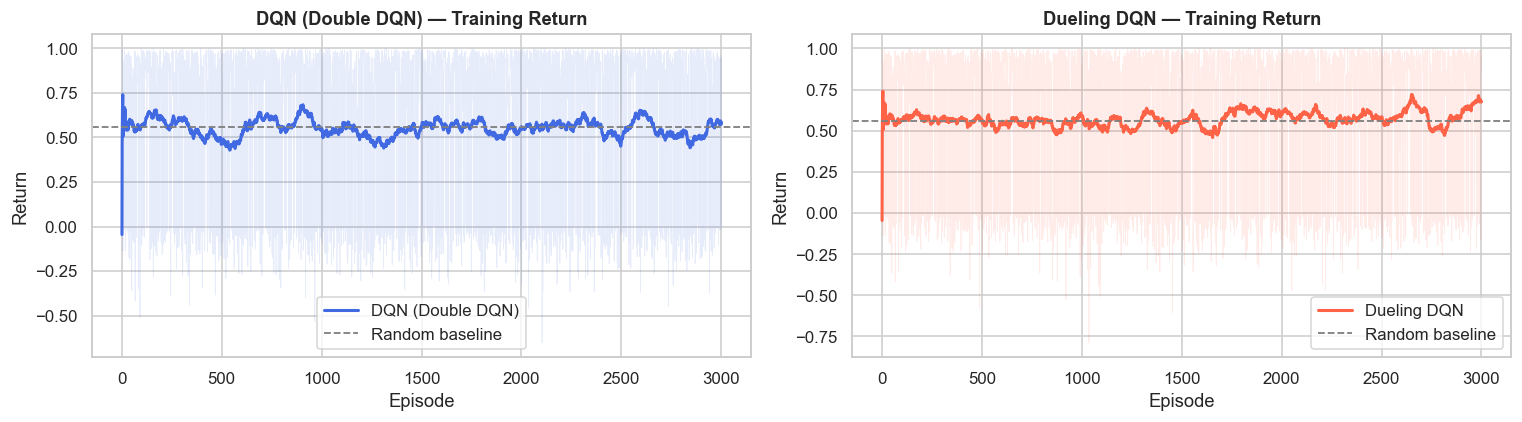

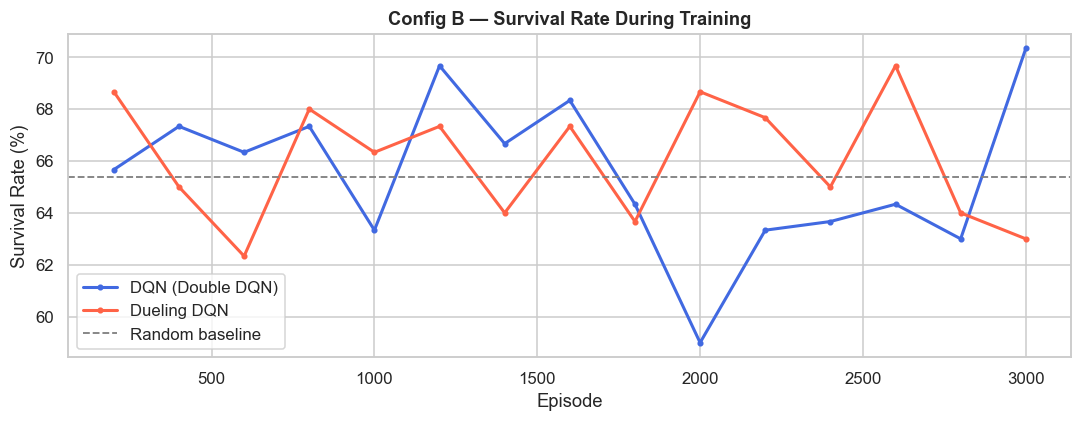

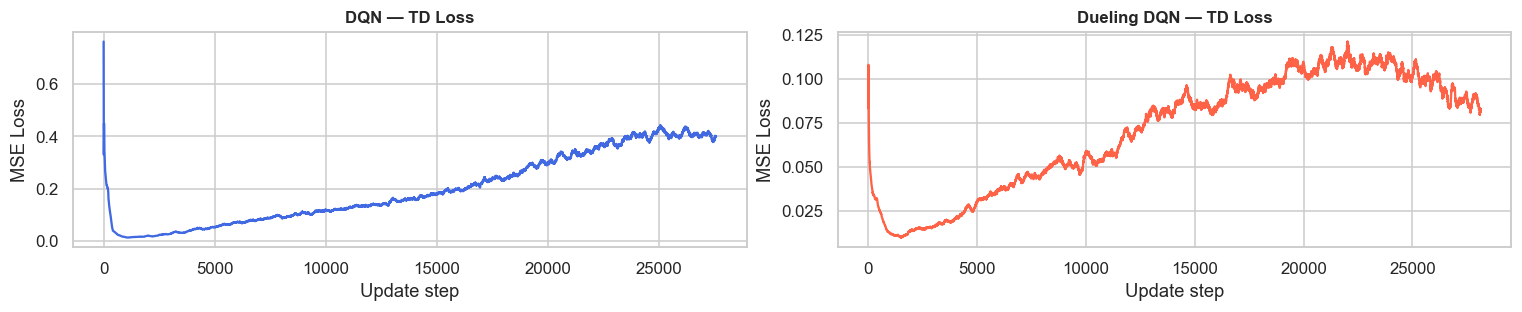

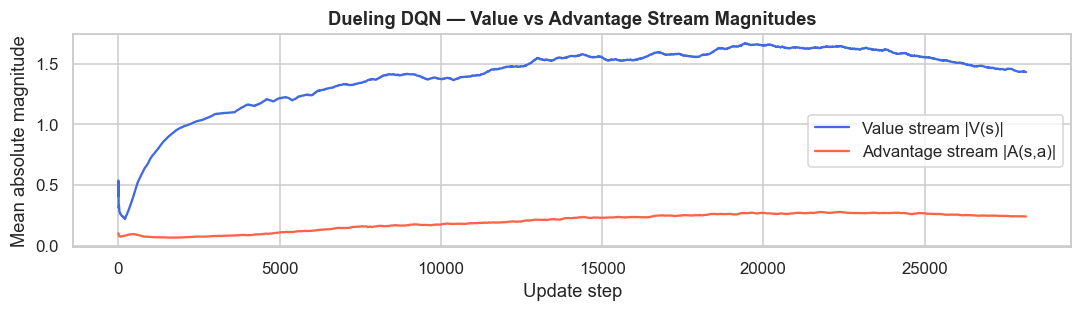

Config B — Final Results (500 eval episodes, greedy policy)
                  Mean Return  Survival Rate (%) Avg Ep Length
Algorithm                                                     
Random Baseline      0.560585               65.4             -
DQN (Double DQN)     0.573065               66.6         10.18
Dueling DQN          0.550510               63.4          9.05


In [18]:
# ── 1. Training reward curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ret, label, c in zip(axes,
    [dqn_train_ret, duel_train_ret],
    ['DQN (Double DQN)', 'Dueling DQN'],
    ['royalblue', 'tomato']):
    ep = np.arange(1, len(ret) + 1)
    ax.plot(ep, ret, alpha=0.12, color=c, lw=0.5)
    ax.plot(ep, smooth(ret, 100), color=c, lw=2, label=label)
    ax.axhline(RAND_B_RETURN, color='grey', ls='--', lw=1.2, label='Random baseline')
    ax.set_title(f'{label} — Training Return', fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Return'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_training_curves.png', bbox_inches='tight')
plt.show()

# ── 2. Eval survival convergence ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for edata, label, c in [
    (dqn_eval,  'DQN (Double DQN)', 'royalblue'),
    (duel_eval, 'Dueling DQN',      'tomato'),
]:
    ax.plot([x[0] for x in edata], [x[2] for x in edata],
            marker='o', ms=3, color=c, lw=2, label=label)
ax.axhline(RAND_B_SURVIVAL, color='grey', ls='--', lw=1.2, label='Random baseline')
ax.set_title('Config B — Survival Rate During Training', fontsize=12, fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Survival Rate (%)'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_eval_convergence.png', bbox_inches='tight')
plt.show()

# ── 3. TD Loss curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].plot(smooth(dqn_losses,  200), color='royalblue', lw=1.5, label='DQN')
axes[0].set_title('DQN — TD Loss', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Update step'); axes[0].set_ylabel('MSE Loss')

axes[1].plot(smooth(duel_losses, 200), color='tomato', lw=1.5, label='Dueling DQN')
axes[1].set_title('Dueling DQN — TD Loss', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Update step'); axes[1].set_ylabel('MSE Loss')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_loss_curves.png', bbox_inches='tight')
plt.show()

# ── 4. Dueling DQN stream magnitudes ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(smooth(val_log, 200), color='royalblue', lw=1.5, label='Value stream |V(s)|')
ax.plot(smooth(adv_log, 200), color='tomato',    lw=1.5, label='Advantage stream |A(s,a)|')
ax.set_title('Dueling DQN — Value vs Advantage Stream Magnitudes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Update step'); ax.set_ylabel('Mean absolute magnitude'); ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/B_dueling_streams.png', bbox_inches='tight')
plt.show()

# ── 5. Results table ──────────────────────────────────────────────────────────
results_B = pd.DataFrame([
    {'Algorithm': 'Random Baseline', 'Mean Return': RAND_B_RETURN,
     'Survival Rate (%)': RAND_B_SURVIVAL, 'Avg Ep Length': '-'},
    {'Algorithm': 'DQN (Double DQN)', 'Mean Return': dqn_mean,
     'Survival Rate (%)': dqn_surv,  'Avg Ep Length': dqn_len},
    {'Algorithm': 'Dueling DQN',      'Mean Return': duel_mean,
     'Survival Rate (%)': duel_surv, 'Avg Ep Length': duel_len},
]).set_index('Algorithm')

print('=' * 60)
print('Config B — Final Results (500 eval episodes, greedy policy)')
print('=' * 60)
print(results_B.to_string())


---
# Config A vs Config B — Comparative Analysis

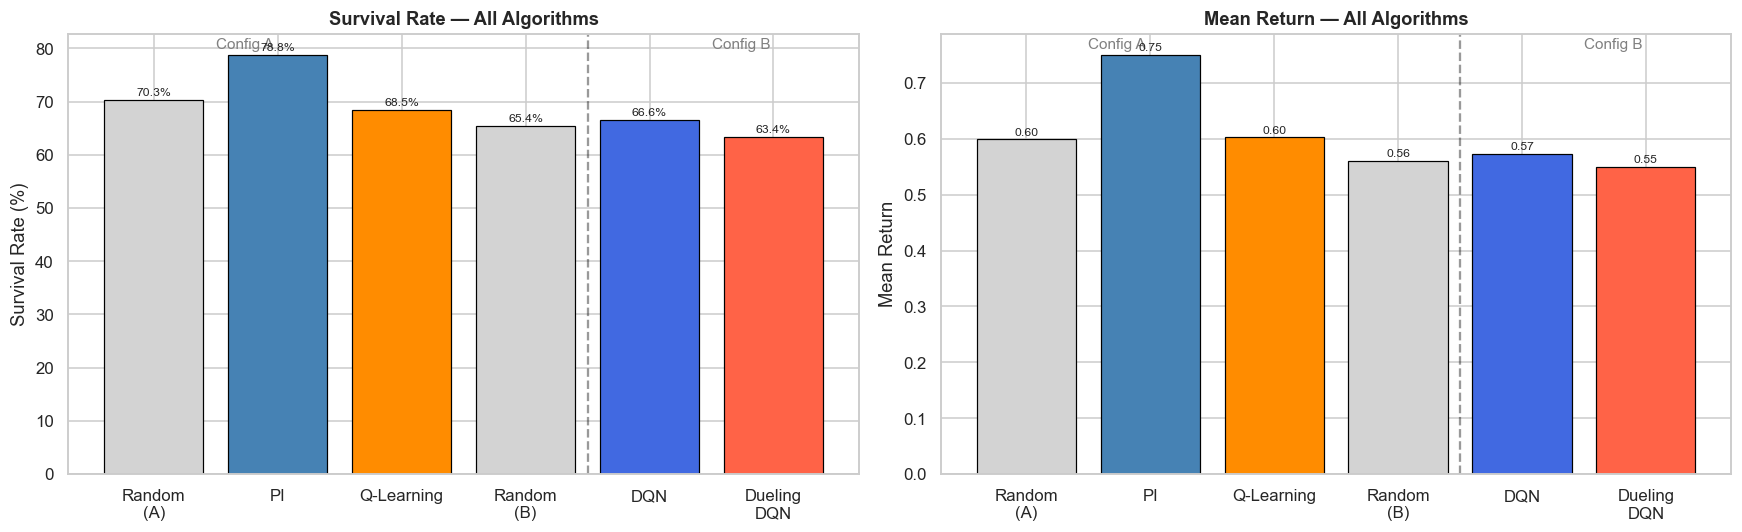

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

algorithms = ['Random\n(A)', 'PI', 'Q-Learning',
              'Random\n(B)', 'DQN', 'Dueling\nDQN']
survivals  = [RAND_A_SURVIVAL, PI_surv, ql_surv,
              RAND_B_SURVIVAL, dqn_surv, duel_surv]
mean_rets  = [RAND_A_RETURN,   PI_mean, ql_mean,
              RAND_B_RETURN,   dqn_mean, duel_mean]
colors     = ['lightgrey', 'steelblue', 'darkorange',
              'lightgrey', 'royalblue', 'tomato']

for ax, values, ylabel, title in zip(axes,
    [survivals, mean_rets],
    ['Survival Rate (%)', 'Mean Return'],
    ['Survival Rate — All Algorithms', 'Mean Return — All Algorithms']):
    bars = ax.bar(algorithms, values, color=colors, edgecolor='black', lw=0.8)
    ax.axvline(3.5, color='black', lw=1.5, ls='--', alpha=0.4)
    ax.text(0.5,  max(values) * 1.015, 'Config A', fontsize=10, color='grey')
    ax.text(4.5,  max(values) * 1.015, 'Config B', fontsize=10, color='grey')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.005,
                f'{v:.2f}' if ylabel == 'Mean Return' else f'{v:.1f}%',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/comparative_all.png', bbox_inches='tight')
plt.show()

---
# Creative Extension — Clinical Interpretability & Treatment Strategy Analysis

## Motivation

A high survival rate alone is insufficient to validate a clinical RL agent. 
ICU clinicians must also trust *how* the agent acts — an agent that survives 
patients through aggressive overmedication causes fluid overload and ischaemia, 
violating the core clinical principle of *primum non nocere* (first, do no harm).

The 25 discrete actions in this environment form a **5×5 treatment grid**: 
vasopressor level (0 = none → 4 = max) × IV fluid dose (0 = none → 4 = max). 
This structure allows us to directly inspect the treatment strategy each agent 
learns, rather than treating actions as opaque indices.

We address two questions:
1. **What treatment strategy does each agent learn?** — measured via action 
   frequency across the vasopressor × fluid grid.
2. **Is high-intensity treatment associated with better or worse outcomes?** — 
   measured via survival rate per action cell, compared against the random baseline.

This analysis is applied to all four trained agents (Policy Iteration, Q-Learning, 
DQN, Dueling DQN), enabling a direct cross-config comparison of learned clinical 
behaviour.

In [31]:
def collect_action_distribution(policy_fn, n_episodes=1000, seed=SEED):
    """Collect action frequency and per-action survival rate."""
    np.random.seed(seed)
    env_eval = make_clinical_env()
    action_counts = np.zeros(ACT_DIM)
    survival_by_action = [[] for _ in range(ACT_DIM)]

    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        ep_actions, total_r, done = [], 0.0, False
        while not done:
            action = policy_fn(obs)
            ep_actions.append(action)
            action_counts[action] += 1
            obs, r, te, tr, _ = env_eval.step(action)
            total_r += r; done = te or tr
        for a in ep_actions:
            survival_by_action[a].append(float(total_r > 0))

    env_eval.close()
    action_freq = action_counts / action_counts.sum()
    surv_by_act = np.array([
        float(np.mean(survival_by_action[a])) if survival_by_action[a] else float('nan')
        for a in range(ACT_DIM)
    ])
    return action_freq, surv_by_act


def random_policy(obs):
    return np.random.randint(ACT_DIM)


print('Collecting action distributions...')
rand_freq,  rand_surv_by_act = collect_action_distribution(random_policy)
dqn_freq,   dqn_surv_by_act  = collect_action_distribution(dqn_policy)
duel_freq,  duel_surv_by_act  = collect_action_distribution(duel_policy)
print('Done.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Done.


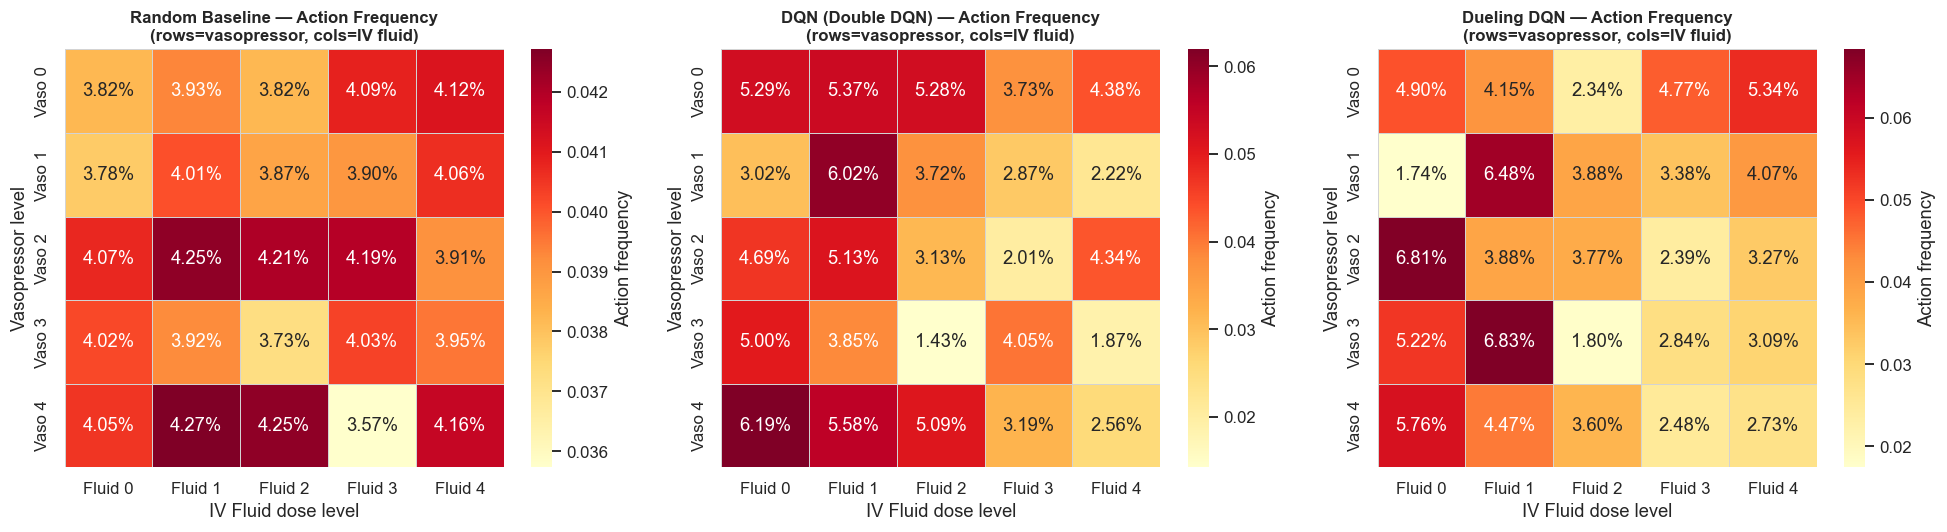

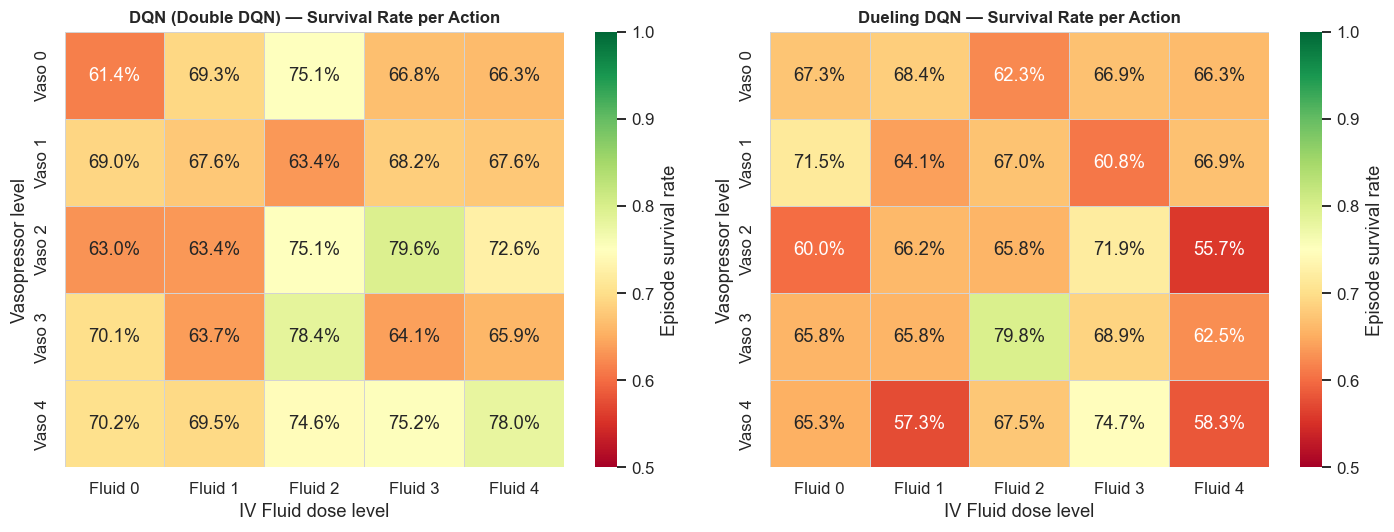

In [ ]:
def to_grid(arr): return arr.reshape(5, 5)

# ── Action frequency heatmaps (5×5) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, freq, title in zip(axes,
    [rand_freq, dqn_freq, duel_freq],
    ['Random Baseline', 'DQN (Double DQN)', 'Dueling DQN']):
    sns.heatmap(
        to_grid(freq), ax=ax, cmap='YlOrRd', annot=True, fmt='.2%',
        xticklabels=[f'Fluid {i}' for i in range(5)],
        yticklabels=[f'Vaso {i}'  for i in range(5)],
        cbar_kws={'label': 'Action frequency'},
        linewidths=0.5, linecolor='lightgrey',
    )
    ax.set_title(f'{title} — Action Frequency\n(rows=vasopressor, cols=IV fluid)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('IV Fluid dose level'); ax.set_ylabel('Vasopressor level')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ext_action_heatmaps.png', bbox_inches='tight')
plt.show()

# ── Survival rate per action heatmaps ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surv, title in zip(axes,
    [dqn_surv_by_act, duel_surv_by_act],
    ['DQN (Double DQN)', 'Dueling DQN']):
    sns.heatmap(
        to_grid(surv), ax=ax, cmap='RdYlGn', annot=True, fmt='.1%',
        xticklabels=[f'Fluid {i}' for i in range(5)],
        yticklabels=[f'Vaso {i}'  for i in range(5)],
        vmin=0.5, vmax=1.0,
        cbar_kws={'label': 'Episode survival rate'},
        linewidths=0.5, linecolor='lightgrey',
    )
    ax.set_title(f'{title} — Survival Rate per Action',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('IV Fluid dose level'); ax.set_ylabel('Vasopressor level')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ext_survival_by_action.png', bbox_inches='tight')
plt.show()


---
# Final Results Summary

In [34]:
print('=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)

print('\n--- Config A (Tabular) ---')
print(results_A.round(4).to_string())

print('\n--- Config B (Deep RL) ---')
print(results_B.round(4).to_string())

print('\n--- Plots saved ---')
for f in sorted(os.listdir(PLOTS_DIR)):
    print(f'   {f}')


FINAL RESULTS SUMMARY

--- Config A (Tabular) ---
                  Mean Return  Survival Rate (%)  Avg Episode Length
Algorithm                                                           
Random Baseline        0.5994               70.3              10.423
Policy Iteration       0.7507               78.8               9.807
Q-Learning             0.6029               68.5               9.927

--- Config B (Deep RL) ---
                  Mean Return  Survival Rate (%) Avg Ep Length
Algorithm                                                     
Random Baseline        0.5606               65.4             -
DQN (Double DQN)       0.5731               66.6         10.18
Dueling DQN            0.5505               63.4          9.05

--- Plots saved ---
   A_PI_convergence.png
   A_convergence_comparison.png
   A_epsilon.png
   A_eval_convergence.png
   A_exploration.png
   A_policy_agreement.png
   A_qtable_heatmap.png
   A_survival_comparison.png
   A_training_curves.png
   A_value_functi